# 01 — Data Exploration (robust)
Loads the graph via `src.dataset.ensure_loaded`, which purges corrupt caches and falls back to the Hugging Face / synthetic generator instead of raising `EmptyDataError`.

In [1]:
#
# robust import setup: repo root on path
import json
import os
import subprocess
import sys
from pathlib import Path

repo = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo))
os.chdir(repo if (repo / "src").exists() else Path.cwd())
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from src.data_pipeline.features import FEATURE_COLUMNS
from src.dataset import ensure_loaded

## Graph topology overview

In [2]:
data = ensure_loaded(root="data")
print(f"nodes={data.num_nodes:,} edges={data.num_edges:,}")
ei = data.edge_index
import torch

src_deg, dst_deg = torch.tensor([]), torch.tensor([])
if data.num_edges:
    src_deg = torch.bincount(ei[0], minlength=data.num_nodes).float()
    dst_deg = torch.bincount(ei[1], minlength=data.num_nodes).float()
print(f"avg out-degree={src_deg.mean():.2f} avg in-degree={dst_deg.mean():.2f}")
labels = data.y.cpu().numpy()
counts = pd.Series(labels).value_counts()
print(counts.to_string())

[PyG Dataset] Downloading dataset from Hugging Face 'qubit420/ibm-aml-LI-smaller'...


README.md:   0%|          | 0.00/817 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  142MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 35.6MB            

...

Generating test split:   0%|          | 0/692405 [00:00<?, ? examples/s]

[PyG Dataset] Successfully downloaded and saved raw CSV data.
[2026-08-27 20:54:28,679] [INFO] [src.data_pipeline.ingestion] Generated 400 synthetic transactions over 200 accounts (2.00% flagged)


[2026-08-27 20:54:28,701] [INFO] [src.data_pipeline.graph_builder] Built graph: 194 nodes, 400 edges, 9 node features, 2 edge features


nodes=194 edges=400
avg out-degree=2.06 avg in-degree=2.06
0    190
1      4


Processing...
Processing...


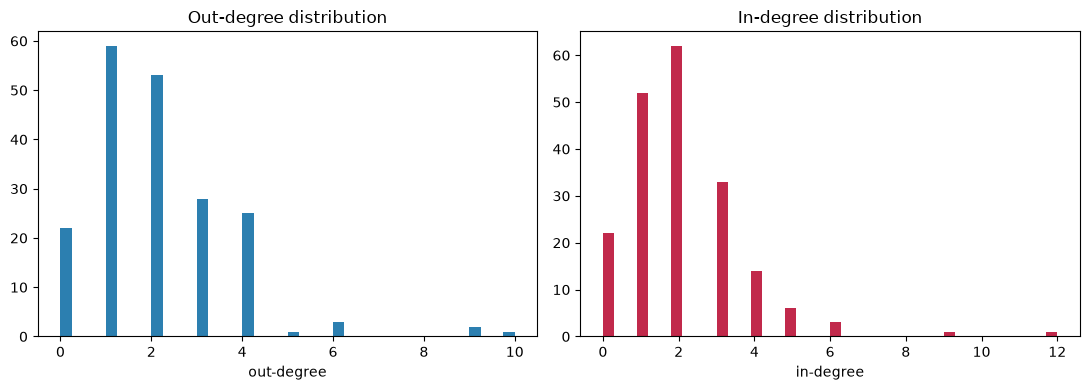

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(src_deg.numpy(), bins=40, color="#2c7fb0")
axes[0].set_title("Out-degree distribution")
axes[0].set_xlabel("out-degree")
axes[1].hist(dst_deg.numpy(), bins=40, color="#c1294b")
axes[1].set_title("In-degree distribution")
axes[1].set_xlabel("in-degree")
plt.tight_layout()
plt.show()

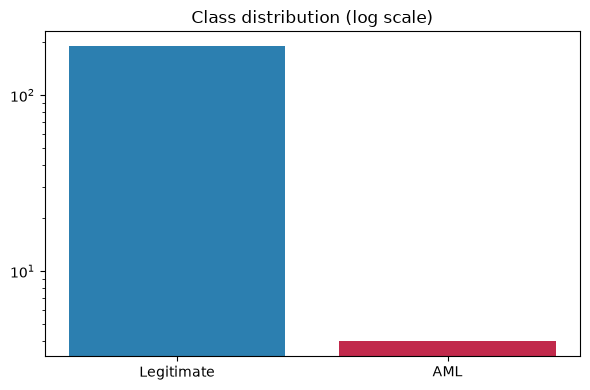

AML ratio = 2.062%


In [4]:
legit, aml = pd.Series(labels).value_counts().reindex([0, 1], fill_value=0)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Legitimate", "AML"], [legit, aml], color=["#2c7fb0", "#c1294b"])
ax.set_yscale("log")
ax.set_title("Class distribution (log scale)")
plt.tight_layout()
plt.show()
print(f"AML ratio = {aml / max(len(labels), 1):.3%}")

## Node feature table (new feature engineering pipeline)

In [5]:
from src.data_pipeline.features import compute_node_features
from src.data_pipeline.graph_builder import build_pyg_data
from src.data_pipeline.ingestion import fetch_transactions, generate_synthetic_transactions

df = generate_synthetic_transactions(n_accounts=60, n_transactions=200, seed=7)
feat = compute_node_features(df)
print(f"{len(FEATURE_COLUMNS)} engineered features")
feat.head()

[2026-08-27 20:54:29,047] [INFO] [src.data_pipeline.ingestion] Generated 200 synthetic transactions over 60 accounts (2.00% flagged)


9 engineered features


,out_degree,mean_amount_sent,total_amount_sent,in_degree,mean_amount_received,total_amount_received,sent_velocity,received_velocity,mean_inter_tx_seconds,label
account,,,,,,,,,,
0,1.0,140.080000,140.08,1.0,15.20,15.20,0.0,1.0,298300.000000,0
1,0.0,0.000000,0.00,5.0,72.71,363.55,0.0,0.0,298300.000000,0
2,1.0,463.790000,463.79,4.0,63.06,252.24,0.0,1.0,298300.000000,0
3,7.0,143.257143,1002.80,3.0,113.80,341.40,4.0,0.0,34428.166667,0
4,1.0,104.250000,104.25,1.0,125.92,125.92,0.0,1.0,298300.000000,0
